# DATA ANALYSIS PYTHON PROJECT - BLINKIT ANALYSIS

#### **Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### **Import Raw Data**

In [2]:
data = pd.read_csv("/content/blinkit_data.csv")

#### **Sample Data**

In [3]:
data.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


#### **Basic checks**

In [4]:
data.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [5]:
data.describe(include="O")

,Item Fat Content,Item Identifier,Item Type,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type
count,8523,8523,8523,8523,8523,8523,8523
unique,5,1559,16,10,3,3,4
top,Low Fat,FDW13,Fruits and Vegetables,OUT027,Tier 3,Medium,Supermarket Type1
freq,5089,10,1232,935,3350,3631,5577


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


#### **Shape of Data**

In [7]:
data.shape

(8523, 12)

#### **Field info**

In [8]:
data.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

#### **Data Type**

In [9]:
data.dtypes

,0
Item Fat Content,object
Item Identifier,object
Item Type,object
Outlet Establishment Year,int64
Outlet Identifier,object
Outlet Location Type,object
Outlet Size,object
Outlet Type,object
Item Visibility,float64
Item Weight,float64


#### **Data Cleaning**

In [10]:
print(data['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [11]:
data['Item Fat Content'] = data['Item Fat Content'].replace({'LF':'Low Fat',
                                                             'low fat':'Low Fat',
                                                             'reg':'Regular'})

In [12]:
print(data['Item Fat Content'].unique())

['Regular' 'Low Fat']


## **BUSINESS REQUIREMENTS**

#### **KPI's REQUIREMENTS**

In [13]:
# Total sales
total_sales = data['Sales'].sum()

# Average Sales
avg_sales = data['Sales'].mean()

# Number of Items Sold
no_of_item_sold = data['Sales'].count()

# Average Rating
avg_rating = data['Rating'].mean()

# Display
print(f'Total Sales: ${total_sales:,.1f}')
print(f'Average Sales: ${avg_sales:,.1f}')
print(f'Number of Items Sold: {no_of_item_sold}')
print(f'Average Rating: {avg_rating:,.1f}')

Total Sales: $1,201,681.5
Average Sales: $141.0
Number of Items Sold: 8523
Average Rating: 4.0


## **CHARTS REQUIREMENTS**

#### **Total Sales by Fat Content**

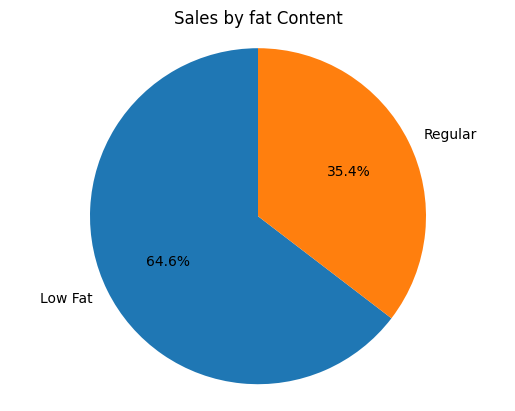

In [14]:
sales_by_fat = data.groupby('Item Fat Content')['Sales'].sum()

plt.pie(sales_by_fat, labels=sales_by_fat.index, autopct='%.1f%%',
        startangle=90)
plt.title('Sales by fat Content')
plt.axis('equal')
plt.show()

#### **Total Sales by Item Type**

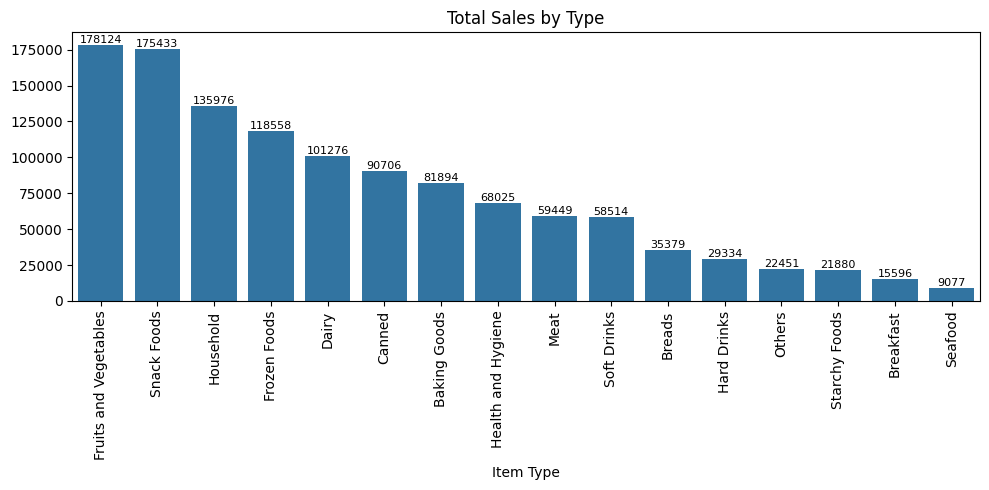

In [15]:
sales_by_type = data.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
ax = sns.barplot(x=sales_by_type.index, y=sales_by_type.values)

for i in ax.patches:
  ax.text(
      i.get_x() + i.get_width()/2,
      i.get_height(),
      int(i.get_height()),
      ha='center',va='bottom',
      fontsize=8
  )
plt.title('Total Sales by Type')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### **Fat Content by Outlet for Total Sales**

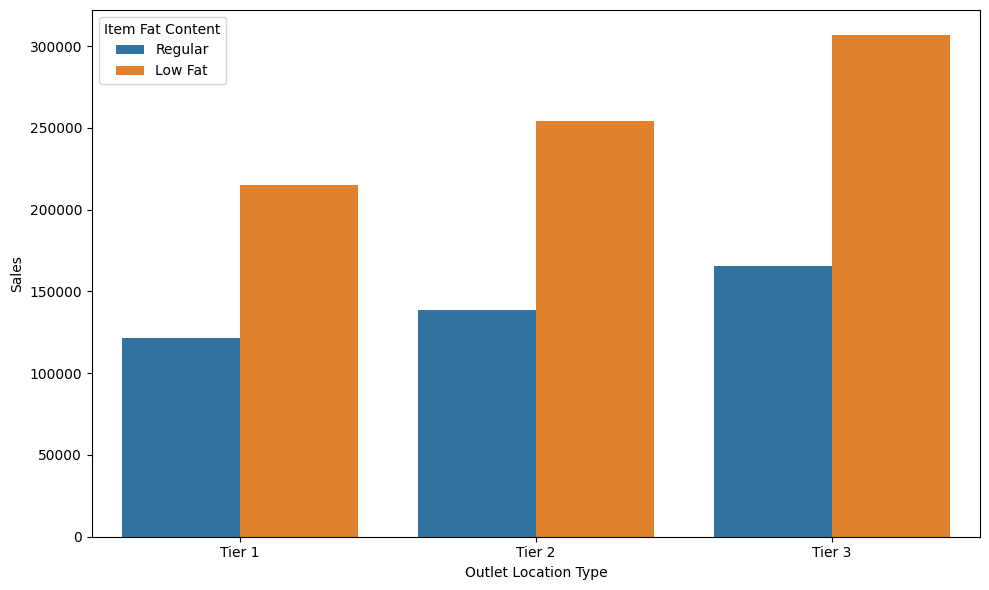

In [16]:
grouped = data.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().reset_index()

plt.figure(figsize=(10,6))
ax = sns.barplot(data=grouped,x='Outlet Location Type',y='Sales',
                 hue='Item Fat Content',hue_order=['Regular', 'Low Fat'])

plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()

#### **Total Sales by Outlet Establishment**

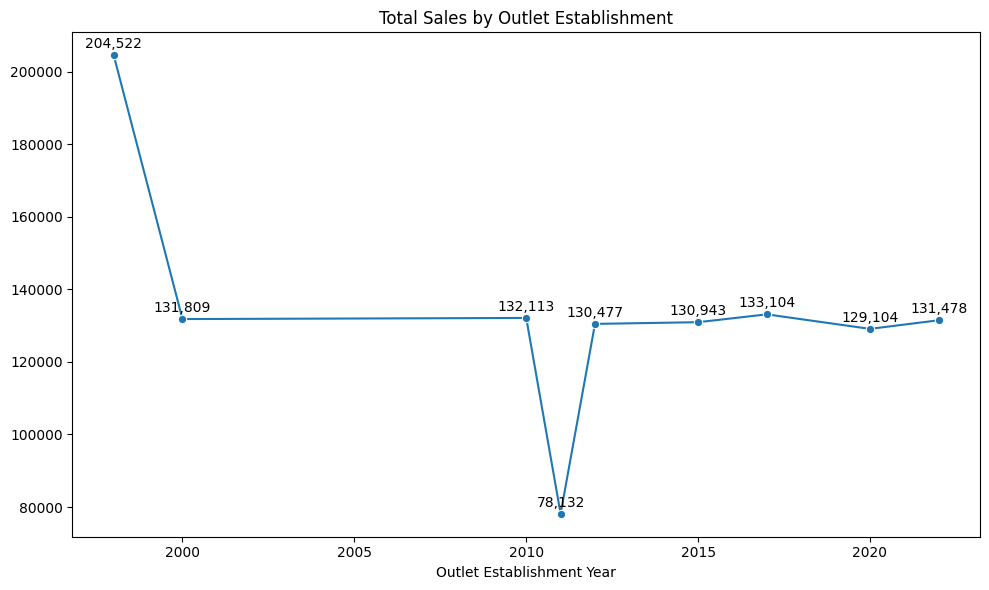

In [17]:
from matplotlib.lines import lineStyles
sales_by_year = data.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(10,6))
sns.lineplot(x=sales_by_year.index, y=sales_by_year.values,
             marker='o', )

for x, y in zip(sales_by_year.index, sales_by_year.values):
  plt.text(x,y +2000 ,
           f'{y:,.0f}',
           ha='center')

plt.title('Total Sales by Outlet Establishment')
plt.tight_layout()
plt.show()

#### **Sales by Outlet Size**

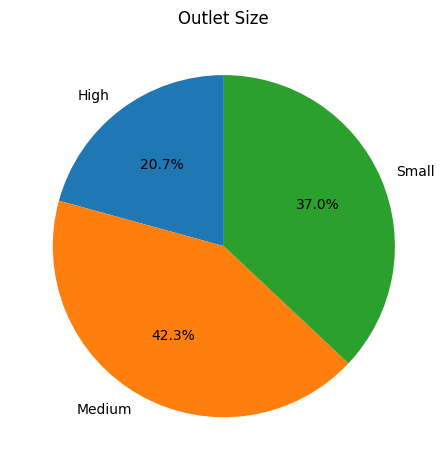

In [18]:
from matplotlib import figure
sales_by_size = data.groupby('Outlet Size')['Sales'].sum()

ax = plt.pie(sales_by_size, labels=sales_by_size.index,
             autopct='%1.1f%%', startangle=90)

plt.title('Outlet Size')
plt.tight_layout()
plt.show()

#### **Sales by Outlet Location**

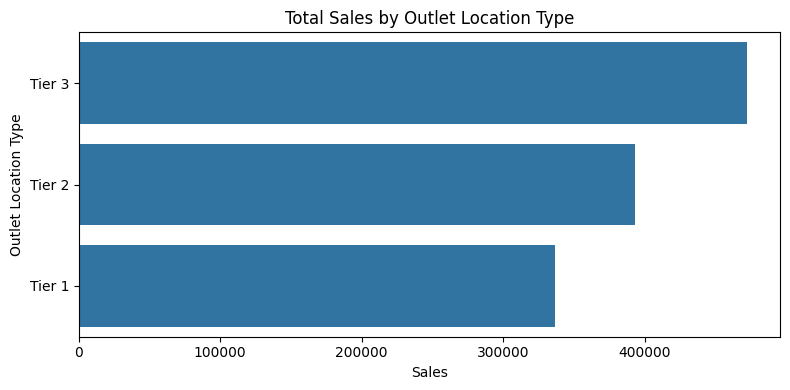

In [19]:
sales_by_location = data.groupby('Outlet Location Type')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)

plt.figure(figsize=(8,4))
ax = sns.barplot(x='Sales', y='Outlet Location Type', data=sales_by_location)

plt.title('Total Sales by Outlet Location Type')
plt.tight_layout()
plt.show()